In [1]:
from pathlib import Path
from typing import List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import pytorch_lightning as pl
from torch.utils.data import DataLoader, Dataset
import plotly.graph_objects as go
from statsmodels.tsa.stattools import adfuller
import math
import functools

import sys
import os
if not sys.warnoptions:
    import warnings
    warnings.simplefilter("ignore")
    
os.environ["CUDA_VISIBLE_DEVICES"]="0"

# TNC SSL Training 

In [2]:
class TNCDataset(Dataset):
    def __init__(
        self,
        data: np.ndarray,
        mc_sample_size: int,
        window_size: int,
        state: float = None,
        adf: bool = True,
        augmentation: int = 1  # Simply repeat the vecvor 'augmentation' times
    ):
        super().__init__()
        self.time_series = data
        self.T = data.shape[-1]
        self.window_size = window_size
        self.sliding_gap = int(window_size * 25.2)
        self.window_per_sample = (self.T - 2 * self.window_size) // self.sliding_gap
        self.mc_sample_size = mc_sample_size
        self.state = state
        self.adf = adf
        self.epsilon = None
        self.augmentation = augmentation

    def __len__(self):
        return len(self.time_series) * self.augmentation

    # @functools.cache
    def __getitem__(self, ind):
        ind = ind % len(self.time_series)       # To repeat augmentation
        t = np.random.randint(2 * self.window_size, self.T - 2 * self.window_size)
        x_t = self.time_series[ind][
            :, t - self.window_size // 2 : t + self.window_size // 2
        ]
        X_close = self._find_neighours(self.time_series[ind], t)
        X_distant = self._find_non_neighours(self.time_series[ind], t)

        if self.state is None:
            y_t = -1
        else:
            y_t = np.round(
                np.mean(
                    self.state[ind][
                        t - self.window_size // 2 : t + self.window_size // 2
                    ]
                )
            )
        return (
            x_t.astype(np.float32),
            X_close.astype(np.float32),
            X_distant.astype(np.float32),
            y_t,
        )

    def _find_neighours(self, x, t):
        T = self.time_series.shape[-1]

        # ---- Do the ADF test ----
        gap = self.window_size
        corr = []
        for w_t in range(self.window_size, 4 * self.window_size, gap):
            try:
                p_val = 0
                for f in range(x.shape[-2]):
                    p = adfuller(
                        np.array(
                            x[
                                f, max(0, t - w_t) : min(x.shape[-1], t + w_t)
                            ].reshape(
                                -1,
                            )
                        )
                    )[1]
                    p_val += 0.01 if math.isnan(p) else p
                corr.append(p_val / x.shape[-2])
            except:
                corr.append(0.6)
        self.epsilon = (
            len(corr)
            if len(np.where(np.array(corr) >= 0.01)[0]) == 0
            else (np.where(np.array(corr) >= 0.01)[0][0] + 1)
        )
        self.delta = 5 * self.epsilon * self.window_size
        # --------------------------

        ## Random from a Gaussian
        t_p = [
            int(t + np.random.randn() * self.epsilon * self.window_size)
            for _ in range(self.mc_sample_size)
        ]
        t_p = [
            max(self.window_size // 2 + 1, min(t_pp, T - self.window_size // 2))
            for t_pp in t_p
        ]
        x_p = np.stack(
            [
                x[:, t_ind - self.window_size // 2 : t_ind + self.window_size // 2]
                for t_ind in t_p
            ]
        )
        return x_p

    def _find_non_neighours(self, x, t):
        T = self.time_series.shape[-1]
        if t > T / 2:
            t_n = np.random.randint(
                self.window_size // 2,
                max((t - self.delta + 1), self.window_size // 2 + 1),
                self.mc_sample_size,
            )
        else:
            t_n = np.random.randint(
                min((t + self.delta), (T - self.window_size - 1)),
                (T - self.window_size // 2),
                self.mc_sample_size,
            )
        x_n = np.stack(
            [
                x[:, t_ind - self.window_size // 2 : t_ind + self.window_size // 2]
                for t_ind in t_n
            ]
        )

        if len(x_n) == 0:
            rand_t = np.random.randint(0, self.window_size // 5)
            if t > T / 2:
                x_n = x[:, rand_t : rand_t + self.window_size].unsqueeze(0)
            else:
                x_n = x[:, T - rand_t - self.window_size : T - rand_t].unsqueeze(0)
        return x_n

In [3]:
class Discriminator(torch.nn.Module):
    def __init__(self, input_size, device: str = "cpu"):
        super(Discriminator, self).__init__()
        self.input_size = input_size

        self.model = torch.nn.Sequential(
            torch.nn.Linear(2 * self.input_size, 4 * self.input_size),
            torch.nn.ReLU(inplace=True),
            torch.nn.Dropout(0.5),
            torch.nn.Linear(4 * self.input_size, 1),
        ).to(device)

        torch.nn.init.xavier_uniform_(self.model[0].weight)
        torch.nn.init.xavier_uniform_(self.model[3].weight)

    def forward(self, x, x_tild):
        """
        Predict the probability of the two inputs belonging to the same neighbourhood.
        """
        x_all = torch.cat([x, x_tild], -1)
        p = self.model(x_all)
        return p.view((-1,))

In [4]:
class GRUEncoder(torch.nn.Module):
    def __init__(
        self,
        hidden_size: int = 100,
        in_channel: int = 6,
        encoding_size: int = 10,
        num_layers: int = 1,
        dropout: float = 0.0,
        bidirectional: bool = True,
        device: str = "cpu",
    ):
        super().__init__()
        self.hidden_size = hidden_size
        self.in_channel = in_channel
        self.num_layers = num_layers
        self.encoding_size = encoding_size
        self.bidirectional = bidirectional
        self.device = device
        
        self.rnn = torch.nn.GRU(
            input_size=self.in_channel,
            hidden_size=self.hidden_size,
            num_layers=num_layers,
            batch_first=False,
            dropout=dropout,
            bidirectional=bidirectional,
        ).to(device)

        self.nn = torch.nn.Linear(
            self.hidden_size * (int(self.bidirectional) + 1), self.encoding_size
        ).to(device)

    def forward(self, x):
        x = x.permute(2, 0, 1)

        past = torch.zeros(
            self.num_layers * (int(self.bidirectional) + 1),
            x.shape[1],
            self.hidden_size,
            device=self.device,
        )

        out, _ = self.rnn(x, past)  # out shape = [seq_len, batch_size, num_directions*hidden_size]
        encodings = self.nn(out[-1].squeeze(0))
        return encodings

### TNC Training

The SSL routine used to train the encoder

In [5]:
def one_epoch(dataloader, encoder, discriminator, device, w=0, optimizer=None):
    # loss_fn = torch.nn.BCELoss()
    loss_fn = torch.nn.BCEWithLogitsLoss()
    
    epoch_loss = {
        'train': [],
        'val': []
    }
    epoch_acc = {
        'train': [],
        'val': []
    }
    
    for phase in ['train', 'val']:
        if phase == 'train':
            encoder.train()
            discriminator.train()
        else:
            encoder.eval()
            discriminator.eval()
            
        for x_t, x_p, x_n, _ in dataloader:
            mc_sample = x_p.shape[1]
            batch_size, f_size, len_size = x_t.shape
            x_p = x_p.reshape((-1, f_size, len_size))
            x_n = x_n.reshape((-1, f_size, len_size))
            x_t = np.repeat(x_t, mc_sample, axis=0)
            neighbors = torch.ones((len(x_p))).to(device)
            non_neighbors = torch.zeros((len(x_n))).to(device)
            x_t, x_p, x_n = x_t.to(device), x_p.to(device), x_n.to(device)

            z_t = encoder(x_t)
            z_p = encoder(x_p)
            z_n = encoder(x_n)

            d_p = discriminator(z_t, z_p)
            d_n = discriminator(z_t, z_n)

            p_loss = loss_fn(d_p, neighbors)
            n_loss = loss_fn(d_n, non_neighbors)
            n_loss_u = loss_fn(d_n, neighbors)
            loss = (p_loss + w*n_loss_u + (1-w)*n_loss)/2

            if phase == 'train':
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            # logging the loss
            epoch_loss[phase].append(loss)
            
            # logging the accuracy
            p_acc = torch.sum(torch.nn.Sigmoid()(d_p) > 0.5).item() / len(z_p)
            n_acc = torch.sum(torch.nn.Sigmoid()(d_n) < 0.5).item() / len(z_n)
            epoch_acc[phase].append((p_acc+n_acc)/2)
        
    return epoch_loss, epoch_acc

def print_metrics(loss_dict, acc_dict):

    def generate_min_loss_array(loss_array):
        min_loss = np.inf
        loss_min = np.copy(loss_array)

        for i, loss in enumerate(loss_array):
            if loss < min_loss:
                min_loss = loss
            loss_min[i] = min_loss

        return loss_min

    loss_train = [x.cpu().detach().numpy() for x in loss_dict['train']]
    loss_train_min = generate_min_loss_array(loss_train)
    loss_val = [x.cpu().detach().numpy() for x in loss_dict['val']]
    loss_val_min = generate_min_loss_array(loss_val)
    
    plt.figure()
    plt.plot(loss_train, label='train', color='blue')
    plt.plot(loss_train_min, linestyle='dashed', color='blue')
    plt.plot(loss_val, label='val', color='orange')
    plt.plot(loss_val_min, linestyle='dashed', color='orange')
    plt.title('Train and val loss')
    plt.legend()
    plt.grid()
    plt.show()
    
    plt.savefig('./plots/tnc_loss.png')
    

def train_encoder(encoder, lr, decay, n_epochs, train_loader, val_loader):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    discriminator = Discriminator(encoder.encoding_size, device)
    params = list(discriminator.parameters()) + list(encoder.parameters())
    optimizer = torch.optim.Adam(params, lr=lr, weight_decay=decay)
    
    losses = {
        'train': [],
        'val': []
    }
    accs = {
        'train': [],
        'val': []
    }
    
    best_loss = np.inf
    best_acc = 0
    
    for epoch in range(n_epochs):
        epoch_losses, epoch_accs = one_epoch(train_loader, encoder, discriminator, device, w=0.05, optimizer=optimizer)
        
        for phase in ['train', 'val']:
            losses[phase].append(torch.stack(epoch_losses[phase]).mean())
            accs[phase].append(torch.Tensor(epoch_accs[phase]).mean())
            
        if epoch%10 == 0:
            print(f'Epoch {epoch}/{n_epochs}')
            print(f'Loss =====> Training Loss: {losses["train"][-1]:.3f} \t Training Accuracy: {accs["train"][-1]:.3f} \t Val Loss: {losses["val"][-1]:.3f} \t Val Accuracy: {accs["val"][-1]:.3f}')
        
        if best_loss > losses[phase][-1]:
            best_acc = accs['val'][-1]
            best_loss = losses['val'][-1]
            state = {
                'epoch': epoch,
                'encoder_state_dict': encoder.state_dict(),
                'discriminator_state_dict': discriminator.state_dict(),
                'best_accuracy': best_acc
            }
            torch.save(state, f'./checkpoints/tnc/checkpoint_tnc.tar')
    
    print_metrics(losses, accs)
    
    return encoder, losses, accs
            

In [6]:
# Hyperparameters
encoding_size = 10
window_size = 60
augmentation = 5
batch_size = 10
mc_sample_size = 20
workers = 10

# Training hyperparameters
lr = 1e-3
decay = 1e-5
n_epochs = 150

In [7]:
def load_encoder_data(root_dir: Path):
    # auxiliar function to read a csv file
    def read_file(file_path: Path): 
        X, y = list(), list()   
        for user_file in os.listdir(file_path):
            user_df = pd.read_csv(os.path.join(file_path, user_file))
            user_x = user_df[['accel-x', 'accel-y', 'accel-z', 'gyro-x', 'gyro-y', 'gyro-z']].to_numpy()
            user_y = user_df['standard activity code'].to_numpy()
            
            X.append(user_x)
            y.append(user_y)
            
        return X, y
    
    # auxiliar function to make user data have the same length
    def fix_data_length(users_X, users_y):
        # 1. finding the user with the biggest number of samples
        max_size = 0
        pivot = -1
        for (i, user) in enumerate(users_X):
            if user.shape[0] > max_size:
                max_size = user.shape[0]
                pivot = i
        
        # 2. filling the other users to the max size by making data cyclic
        for i in range(len(users_X)):
            if i == pivot:
                continue
            
            user_x = users_X[i]
            user_y = users_y[i]
            
            user_x = np.concatenate([user_x, user_x[:max_size - user_x.shape[0]]])
            user_y = np.concatenate([user_y, user_y[:max_size - user_y.shape[0]]])
            
            users_X[i] = user_x
            users_y[i] = user_y
            
        X = np.array(users_X).transpose((0, 2, 1)) # (n_users, n_features, n_samples)
        y = np.array(users_y)
            
        return X, y

    X_train1, y_train1 = read_file(os.path.join(root_dir, 'train'))            
    X_train2, y_train2 = read_file(os.path.join(root_dir, 'val'))
    X_val, y_val = read_file(os.path.join(root_dir, 'test'))
    
    # No test set is needed when training the encoder so we merge train and val
    X_train = X_train1 + X_train2
    y_train = y_train1 + y_train2
    
    # Fixing the data length
    X_train, y_train = fix_data_length(X_train, y_train) 
    X_val, y_val = fix_data_length(X_val, y_val)
    
    return X_train, X_val, y_train, y_val         

X_train, X_val, y_train, y_val = load_encoder_data('./data/uci_encoder/')
print(X_train.shape, X_val.shape, y_train.shape, y_val.shape)

train_dataset = TNCDataset(X_train, mc_sample_size=mc_sample_size, window_size=window_size, augmentation=augmentation)
validation_dataset = TNCDataset(X_val, mc_sample_size=mc_sample_size, window_size=window_size, augmentation=augmentation)

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, num_workers=workers, shuffle=True)
validation_dataloader = DataLoader(validation_dataset, batch_size=batch_size, num_workers=workers, shuffle=True)

len(train_dataset), len(validation_dataset)

(24, 6, 9541) (6, 6, 9253) (24, 9541) (6, 9253)


(120, 30)

In [8]:
# Declaring the model and the trainer
discriminator = Discriminator(input_size=encoding_size, device='cuda')
encoder = GRUEncoder(encoding_size=encoding_size, device='cuda')

In [9]:
# Checking if there are weights saved from previous training, else it trains from scratch
try:
    encoder.load_state_dict(torch.load('./weights/tnc_meta4/tnc_encoder.pt'))

except:
    encoder, loss_dict, acc_dict = train_encoder(encoder, lr, decay, n_epochs, train_dataloader, validation_dataloader)
    torch.save(encoder.state_dict(), "./weights/tnc_encoder.pt")

# TNC Fine-tunning

We are going to use the TNC model on the downstream task of classification. We will use same dataset and re-use the same encoder

In [10]:
from typing import Any, Optional

from torchmetrics.functional import accuracy

class StateClassifier(torch.nn.Module):
    def __init__(self, input_size: int = 10, n_classes: int = 6):
        super(StateClassifier, self).__init__()
        self.input_size = input_size
        self.n_classes = n_classes
        self.normalize = torch.nn.BatchNorm1d(self.input_size)
        self.nn = torch.nn.Linear(self.input_size, self.n_classes)
        torch.nn.init.xavier_uniform_(self.nn.weight)

    def forward(self, x):
        x = self.normalize(x)
        logits = self.nn(x)
        return logits
    
class TNC_Classifier(pl.LightningModule):
    def __init__(
        self,
        encoder: torch.nn.Module,
        classifier: torch.nn.Module,
        lr: float = 1e-1,
        weight_decay: float = 0.0,
        task_class: str = "multiclass",
        num_classes: int = 6
    ):
        super().__init__()
        self.encoder = encoder.to(self.device)
        self.classifier = classifier.to(self.device)
        self.learning_rate = lr
        self.weight_decay = weight_decay
        self.training_step_losses = []
        self.validation_step_losses = []
        self.loss_function = torch.nn.CrossEntropyLoss()
        self.task_class = task_class
        self.num_classes = num_classes
        
        self.train_epoch_loss = []
        self.train_epoch_acc = []
        self.val_epoch_loss = []
        self.val_epoch_acc = []
        
    def configure_optimizers(self) -> Any:
        optimizer = torch.optim.Adam(
            self.classifier.parameters(), lr=self.learning_rate, weight_decay=self.weight_decay
        )
        return optimizer
    
    def forward(self, x):
        encodings = self.encoder(x)
        predictions = self.classifier(encodings)
        return predictions
    
    def training_step(self, batch, batch_idx):
        x, y = batch
        predictions = self.forward(x)
        loss = self.loss_function(predictions, y.long())
        self.training_step_losses.append(loss)
        return loss
    
    def on_train_epoch_end(self) -> None:
        # do something with all training_step outputs, for example:
        epoch_mean = torch.stack(self.training_step_losses).mean()
        self.train_epoch_loss.append(epoch_mean.cpu().detach().numpy())
        self.log("train_loss", epoch_mean, on_epoch=True, on_step=False, prog_bar=True, logger=True)
        # free up the memory
        self.training_step_losses.clear()
    
    def validation_step(self, batch, batch_idx):
        loss, acc = self._shared_eval_step(batch, batch_idx)
        self.validation_step_losses.append(loss)
        metrics = {"val_acc": acc, "val_loss": loss}
        self.log_dict(metrics)
        return metrics
    
    def test_step(self, batch, batch_idx):
        loss, acc = self._shared_eval_step(batch, batch_idx)
        metrics = {"test_acc": acc, "test_loss": loss}
        self.log_dict(metrics)
        return metrics
        
    def on_validation_epoch_end(self) -> None:
        # do something with all training_step outputs, for example:
        epoch_mean = torch.stack(self.validation_step_losses).mean()
        self.val_epoch_loss.append(epoch_mean.cpu().detach().numpy())
        self.log("val_loss", epoch_mean, on_epoch=True, on_step=False, prog_bar=True, logger=True)
        # free up the memory
        self.validation_step_losses.clear()

    def _shared_eval_step(self, batch, batch_idx):
        x, y = batch
        predictions = self.forward(x)
        loss = self.loss_function(predictions, y.long())
        acc = accuracy(torch.argmax(predictions, dim=1), y.long(), task=self.task_class, num_classes=self.num_classes)
        return loss, acc
    
class ClassifierPrintMetrics(pl.Callback):
    def on_fit_end(self, trainer, pl_module):
        #train_acc = pl_module.train_acc.compute()
        #val_acc = pl_module.val_acc.compute()
        train_loss = pl_module.train_epoch_loss
        print(train_loss)
        val_loss = pl_module.val_epoch_loss
        
        print(f"\ntrain_loss={train_loss}, val_loss={val_loss}")
        
        # plotting train and val loss
        plt.figure(figsize=(6, 4))
        plt.plot(train_loss, label='train_loss')
        plt.plot(val_loss, label='val_loss')
        plt.legend()
        plt.grid()
        plt.title('Train and Validation Loss')
        plt.savefig('./plots/tnc_classifier_loss.png')
        
        # # plotting train and val acc
        # plt.figure(figsize=(12, 8))
        # plt.plot(train_loss, label='train_loss')
        # plt.plot(val_loss, label='val_loss')
        # plt.legend()
        # plt.title('Train and Validation Loss')
        # plt.savefig('./plots/tnc_classifier_loss.png')


In [11]:
# fine-tunning hyperparams
class_batch_size = 32
class_lr = 1e-3

In [14]:
def load_classifier_data(file_path):
    df = pd.read_csv(file_path)
    X = df.iloc[:, :360].to_numpy()
    X = X.reshape((X.shape[0], 6, 60))
    y = df['standard activity code'].to_numpy()    
    return X, y
        
root_dir = './data/uci_classifier/'
X_train, y_train = load_classifier_data(os.path.join(root_dir, 'train.csv'))
X_val, y_val = load_classifier_data(os.path.join(root_dir, 'validation.csv'))
X_test, y_test = load_classifier_data(os.path.join(root_dir, 'test.csv'))

print(X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape)

classifier_train_dataset = torch.utils.data.TensorDataset(torch.Tensor(X_train), torch.Tensor(y_train))
classifier_validation_dataset = torch.utils.data.TensorDataset(torch.Tensor(X_val), torch.Tensor(y_val))
classifier_test_dataset = torch.utils.data.TensorDataset(torch.Tensor(X_test), torch.Tensor(y_test))

classifier_train_dataloader = DataLoader(classifier_train_dataset, batch_size=class_batch_size, shuffle=True)
classifier_validation_dataloader = DataLoader(classifier_validation_dataset, batch_size=class_batch_size, shuffle=True)
classifier_test_dataloader = DataLoader(classifier_test_dataset, batch_size=class_batch_size, shuffle=True)

(2420, 6, 60) (2420,) (340, 6, 60) (340,) (690, 6, 60) (690,)


In [15]:
n_classes = 6
encoding_size = 10

classifier = StateClassifier(input_size=encoding_size, n_classes=n_classes)
tnc_classifier = TNC_Classifier(encoder, classifier, lr=1e-3)

In [16]:
trainer = pl.Trainer(max_epochs=100, callbacks=ClassifierPrintMetrics(), accelerator="gpu")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


You are using a CUDA device ('NVIDIA A100 80GB PCIe') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type             | Params
---------------------------------------------------
0 | encoder       | GRUEncoder       | 66.8 K
1 | classifier    | StateClassifier  | 86    
2 | loss_function | CrossEntropyLoss | 0     
---------------------------------------------------
66.9 K    Trainable params
0         Non-trainable params
66.9 K    Total params
0.268     Total estimated model params size (MB)


Epoch 99: 100%|██████████| 76/76 [00:00<00:00, 148.41it/s, v_num=0, val_loss=0.341, train_loss=0.382]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: 100%|██████████| 76/76 [00:00<00:00, 138.99it/s, v_num=0, val_loss=0.341, train_loss=0.382]
[array(1.636784, dtype=float32), array(1.1708744, dtype=float32), array(0.94548917, dtype=float32), array(0.80870605, dtype=float32), array(0.7306922, dtype=float32), array(0.6797428, dtype=float32), array(0.64830613, dtype=float32), array(0.61970985, dtype=float32), array(0.59759295, dtype=float32), array(0.5815462, dtype=float32), array(0.570125, dtype=float32), array(0.5610339, dtype=float32), array(0.5462529, dtype=float32), array(0.53433925, dtype=float32), array(0.5216047, dtype=float32), array(0.5281596, dtype=float32), array(0.5089708, dtype=float32), array(0.5038123, dtype=float32), array(0.49620482, dtype=float32), array(0.49535018, dtype=float32), array(0.49332297, dtype=float32), array(0.48278788, dtype=float32), array(0.48611957, dtype=float32), array(0.4694375, dtype=float32), array(0.47109613, dtype=float32), array(0.46357074, dtype=float32), array(0.46869197, dtype=floa

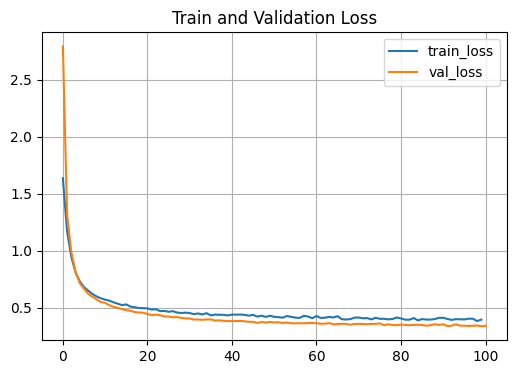

In [17]:
trainer.fit(tnc_classifier, train_dataloaders=classifier_train_dataloader, val_dataloaders=classifier_validation_dataloader)

## Classification evaluation

In [18]:
trainer.test(tnc_classifier, classifier_test_dataloader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing DataLoader 0:  68%|██████▊   | 15/22 [00:00<00:00, 118.05it/s]

Testing DataLoader 0: 100%|██████████| 22/22 [00:00<00:00, 95.35it/s] 


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.7739130258560181     │
│         test_loss         │    0.36142703890800476    │
└───────────────────────────┴───────────────────────────┘

[{'test_acc': 0.7739130258560181, 'test_loss': 0.36142703890800476}]